
グラフ構造
n                                     : 12
m                                     : 22
components                            : 1
density                               : 0.3333333333333333
average_degree                        : 3.6666666666666665
degree_variance                       : 2.388888888888889
graph_rank                            : 11
cyclomatic                            : 11
cycle_basis_count                     : 11
simple_cycle_count                    : nan
girth                                 : 3
triangle_count                        : 9
bridge_count                          : 2
articulation_point_count              : 2
average_clustering                    : 0.3888888888888889
transitivity                          : 0.3698630136986301
average_core                          : 2.5833333333333335
maximum_core                          : 3

独立集合
independent_set_count                 : 180
independent_set_ratio                 : 0.0439453125
maximal_independent_set_co

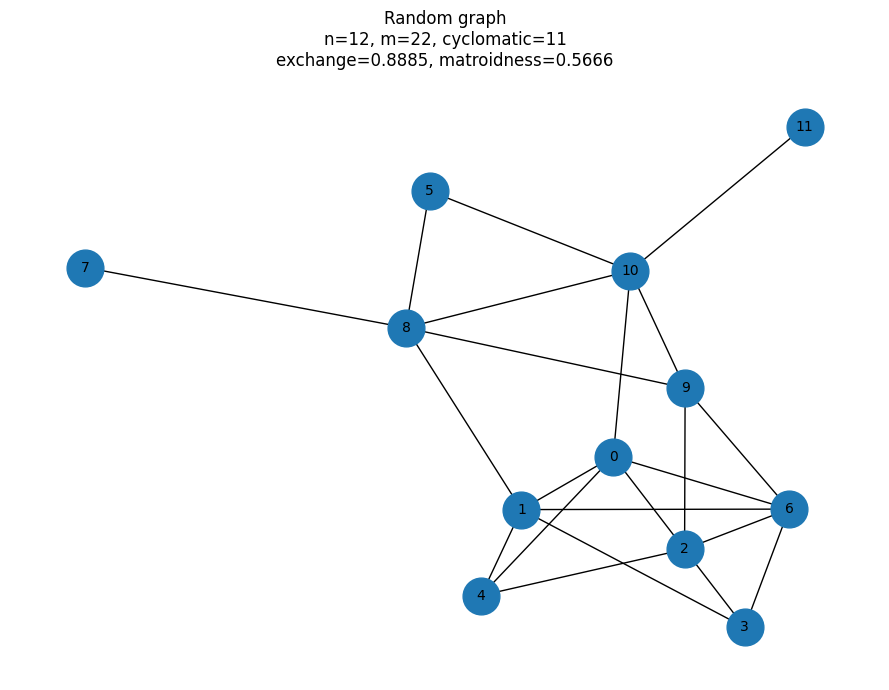

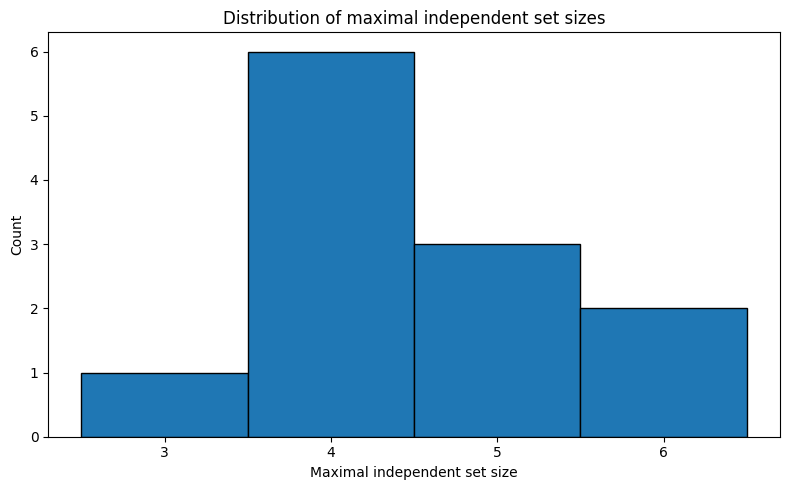

[1/110] type=erdos_renyi, p=0.00, graph=1
[2/110] type=erdos_renyi, p=0.00, graph=2
[3/110] type=erdos_renyi, p=0.00, graph=3
[4/110] type=erdos_renyi, p=0.00, graph=4
[5/110] type=erdos_renyi, p=0.00, graph=5
[6/110] type=erdos_renyi, p=0.00, graph=6
[7/110] type=erdos_renyi, p=0.00, graph=7
[8/110] type=erdos_renyi, p=0.00, graph=8
[9/110] type=erdos_renyi, p=0.00, graph=9
[10/110] type=erdos_renyi, p=0.00, graph=10
[11/110] type=erdos_renyi, p=0.10, graph=1
[12/110] type=erdos_renyi, p=0.10, graph=2
[13/110] type=erdos_renyi, p=0.10, graph=3
[14/110] type=erdos_renyi, p=0.10, graph=4
[15/110] type=erdos_renyi, p=0.10, graph=5
[16/110] type=erdos_renyi, p=0.10, graph=6
[17/110] type=erdos_renyi, p=0.10, graph=7
[18/110] type=erdos_renyi, p=0.10, graph=8
[19/110] type=erdos_renyi, p=0.10, graph=9
[20/110] type=erdos_renyi, p=0.10, graph=10
[21/110] type=erdos_renyi, p=0.20, graph=1
[22/110] type=erdos_renyi, p=0.20, graph=2
[23/110] type=erdos_renyi, p=0.20, graph=3
[24/110] type=erdo

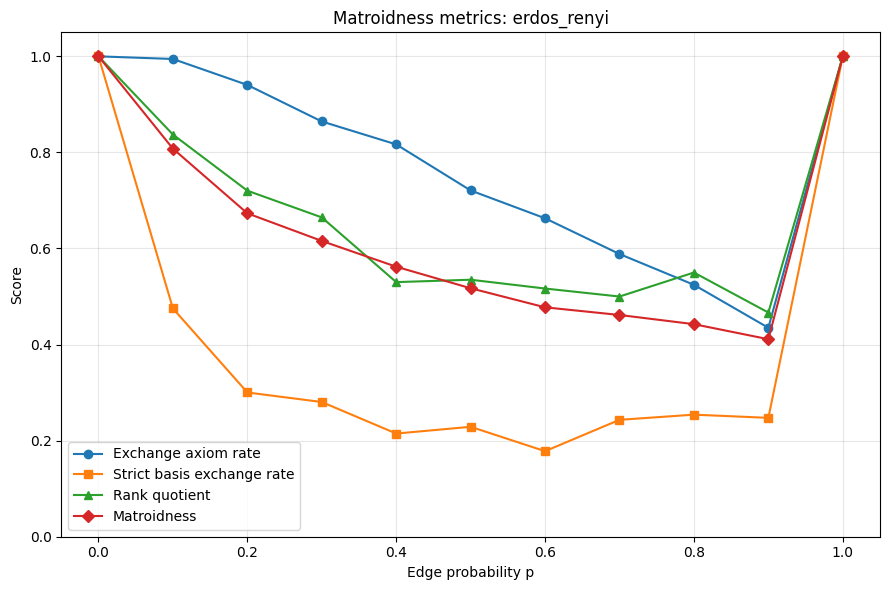

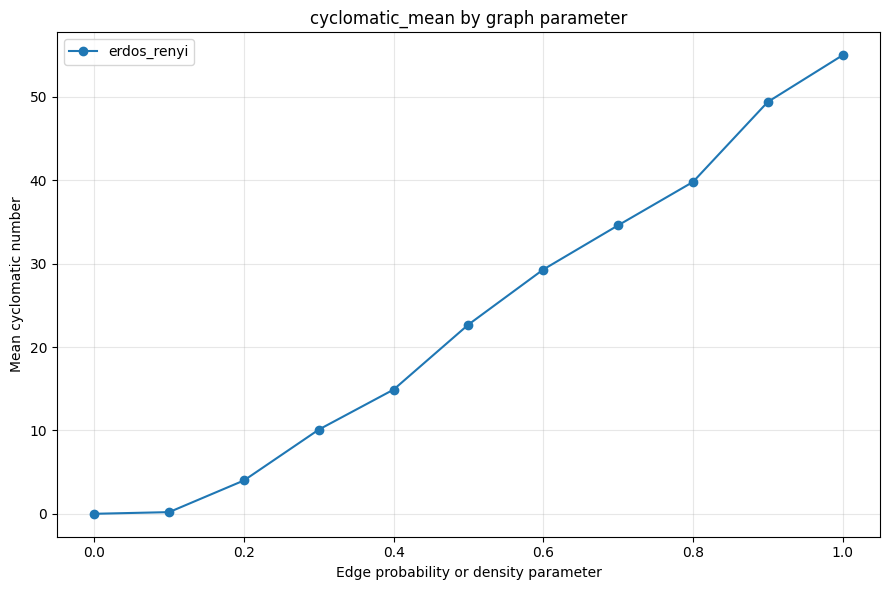

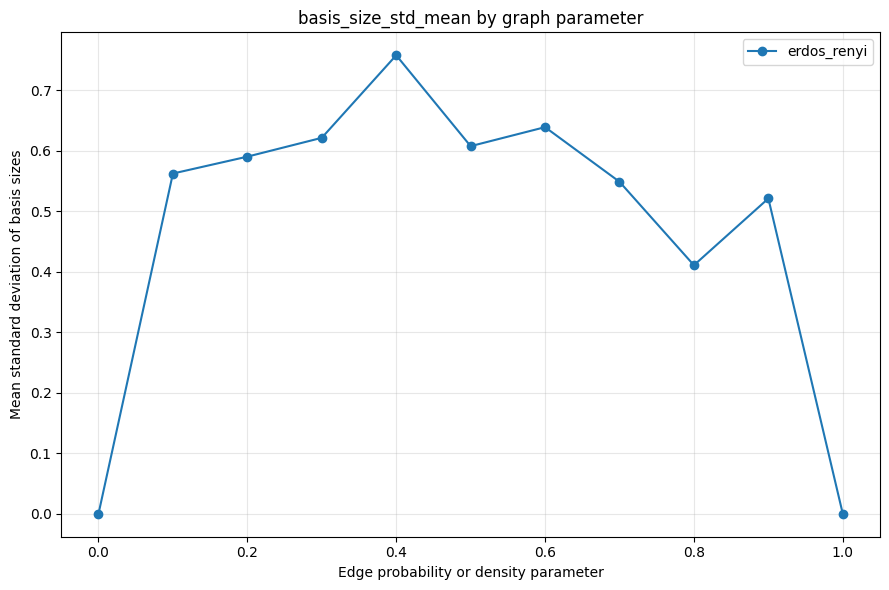

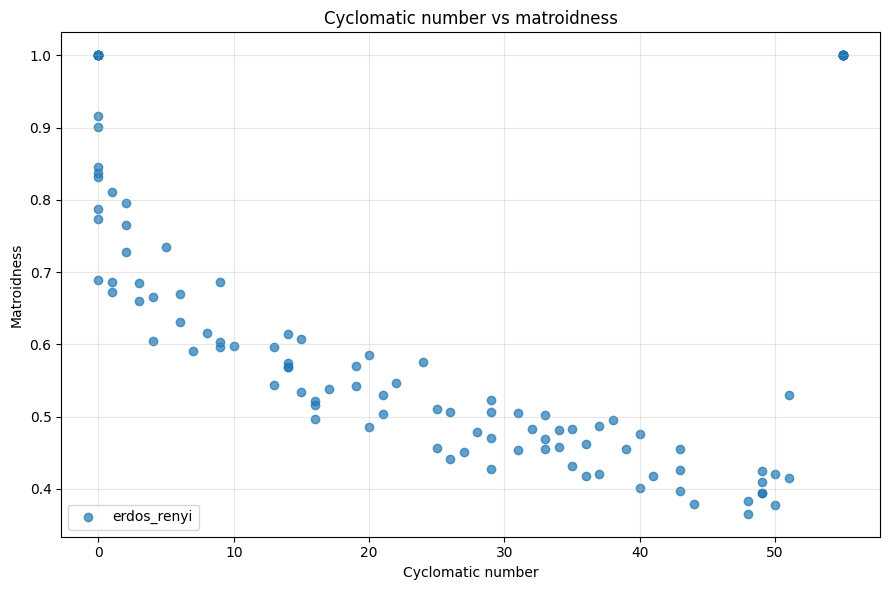

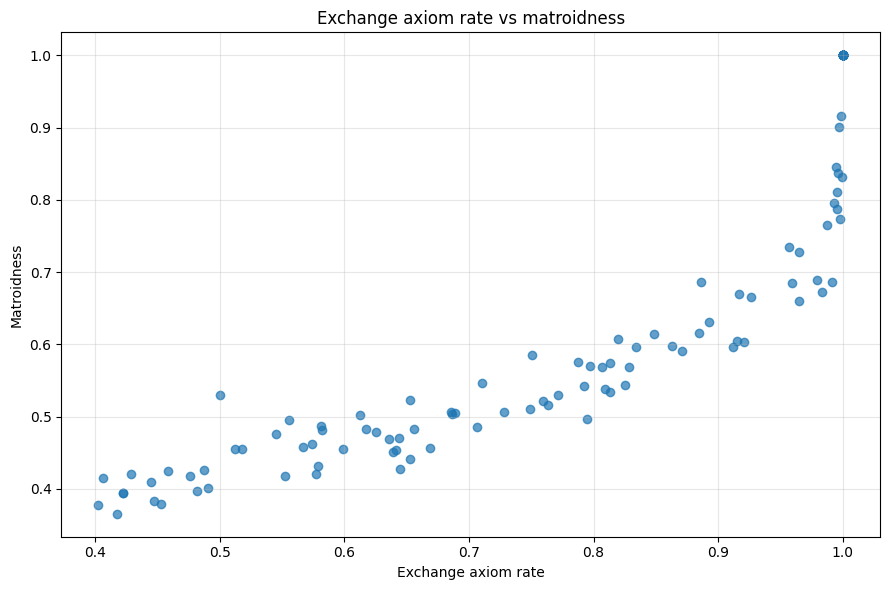

In [1]:
import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd


# =========================================================
# 1. 頂点独立集合の判定
# =========================================================

def is_vertex_independent(
    G: nx.Graph,
    vertex_subset
) -> bool:
    """
    頂点部分集合の内部に辺が存在しなければ独立集合。

    Parameters
    ----------
    G : nx.Graph
        対象グラフ
    vertex_subset : iterable
        頂点部分集合

    Returns
    -------
    bool
        独立集合ならTrue
    """
    vertices = list(vertex_subset)

    for u, v in itertools.combinations(vertices, 2):
        if G.has_edge(u, v):
            return False

    return True


# =========================================================
# 2. 全独立集合の列挙
# =========================================================

def enumerate_independent_sets(
    G: nx.Graph
) -> list[frozenset]:
    """
    全頂点部分集合を調べ、独立集合を列挙する。

    注意
    ----
    計算量は指数的であり、概ね O(2^n)。
    頂点数15程度までを推奨。
    """
    nodes = list(G.nodes())
    independent_sets = []

    for subset_size in range(len(nodes) + 1):
        for subset in itertools.combinations(
            nodes,
            subset_size
        ):
            if is_vertex_independent(G, subset):
                independent_sets.append(
                    frozenset(subset)
                )

    return independent_sets


# =========================================================
# 3. 極大独立集合
# =========================================================

def find_maximal_independent_sets(
    G: nx.Graph,
    independent_sets: list[frozenset]
) -> list[frozenset]:
    """
    頂点を1個も追加できない独立集合を抽出する。

    極大独立集合は、包含関係に関して最大である。
    最大独立集合とは異なる点に注意。
    """
    all_nodes = set(G.nodes())
    maximal_sets = []

    for independent_set in independent_sets:

        remaining_nodes = (
            all_nodes - set(independent_set)
        )

        is_maximal = True

        for vertex in remaining_nodes:

            expanded_set = frozenset(
                set(independent_set) | {vertex}
            )

            if expanded_set in independent_sets:
                is_maximal = False
                break

        if is_maximal:
            maximal_sets.append(independent_set)

    return maximal_sets


# =========================================================
# 4. 最大独立集合
# =========================================================

def find_maximum_independent_sets(
    independent_sets: list[frozenset]
) -> list[frozenset]:
    """
    頂点数が最大の独立集合を抽出する。
    """
    if not independent_sets:
        return []

    maximum_size = max(
        len(independent_set)
        for independent_set in independent_sets
    )

    return [
        independent_set
        for independent_set in independent_sets
        if len(independent_set) == maximum_size
    ]


# =========================================================
# 5. グラフ構造指標
# =========================================================

def graph_rank(G: nx.Graph) -> int:
    """
    グラフィック・マトロイドのランク。

    r(E) = |V| - c(G)
    """
    return (
        G.number_of_nodes()
        - nx.number_connected_components(G)
    )


def cyclomatic_number(G: nx.Graph) -> int:
    """
    サイクロマティック数。

    μ = |E| - |V| + c(G)

    独立な閉路の個数を表す。
    """
    return (
        G.number_of_edges()
        - G.number_of_nodes()
        + nx.number_connected_components(G)
    )


def cycle_basis_count(G: nx.Graph) -> int:
    """
    基本閉路基底に含まれる閉路数。

    無向グラフでは通常、
    サイクロマティック数と一致する。
    """
    return len(nx.cycle_basis(G))


def simple_cycle_count(G: nx.Graph) -> int:
    """
    単純閉路の総数を数える。

    無向グラフを有向グラフへ変換して列挙するため、
    小規模グラフ向け。

    注意
    ----
    閉路が多いグラフでは計算量が非常に大きくなる。
    """
    directed_graph = G.to_directed()

    unique_cycles = set()

    for cycle in nx.simple_cycles(directed_graph):

        if len(cycle) < 3:
            continue

        cycle = list(cycle)

        rotations = []

        for index in range(len(cycle)):
            rotated = (
                cycle[index:]
                + cycle[:index]
            )

            rotations.append(tuple(rotated))
            rotations.append(
                tuple(reversed(rotated))
            )

        canonical_cycle = min(rotations)

        unique_cycles.add(canonical_cycle)

    return len(unique_cycles)


def triangle_count(G: nx.Graph) -> int:
    """
    三角形数。
    """
    return sum(nx.triangles(G).values()) // 3


def bridge_count(G: nx.Graph) -> int:
    """
    橋の数。

    橋とは、削除すると連結成分数が増える辺。
    """
    return len(list(nx.bridges(G)))


def articulation_point_count(G: nx.Graph) -> int:
    """
    関節点の数。

    関節点とは、削除すると連結成分数が増える頂点。
    """
    return len(
        list(nx.articulation_points(G))
    )


def average_degree(G: nx.Graph) -> float:
    """
    平均次数。
    """
    n = G.number_of_nodes()

    if n == 0:
        return 0.0

    return (
        2.0 * G.number_of_edges() / n
    )


def degree_variance(G: nx.Graph) -> float:
    """
    次数の分散。
    """
    if G.number_of_nodes() == 0:
        return 0.0

    degrees = np.array(
        [degree for _, degree in G.degree()],
        dtype=float
    )

    return float(np.var(degrees))


def average_core_number(G: nx.Graph) -> float:
    """
    平均コア数。
    """
    if G.number_of_nodes() == 0:
        return 0.0

    core_numbers = nx.core_number(G)

    return float(
        np.mean(list(core_numbers.values()))
    )


def maximum_core_number(G: nx.Graph) -> int:
    """
    最大コア数。
    """
    if G.number_of_nodes() == 0:
        return 0

    core_numbers = nx.core_number(G)

    return int(max(core_numbers.values()))


def girth(G: nx.Graph) -> int:
    """
    最短閉路長。

    閉路が存在しない場合は0を返す。
    """
    minimum_cycle_length = np.inf

    for source in G.nodes():

        distances = {
            source: 0
        }

        parent = {
            source: None
        }

        queue = [source]

        while queue:

            current = queue.pop(0)

            for neighbor in G.neighbors(current):

                if neighbor not in distances:

                    distances[neighbor] = (
                        distances[current] + 1
                    )

                    parent[neighbor] = current
                    queue.append(neighbor)

                elif parent[current] != neighbor:

                    cycle_length = (
                        distances[current]
                        + distances[neighbor]
                        + 1
                    )

                    minimum_cycle_length = min(
                        minimum_cycle_length,
                        cycle_length
                    )

    if np.isinf(minimum_cycle_length):
        return 0

    return int(minimum_cycle_length)


# =========================================================
# 6. 独立集合に関する基本指標
# =========================================================

def independent_set_ratio(
    G: nx.Graph,
    independent_sets: list[frozenset]
) -> float:
    """
    全頂点部分集合のうち、独立集合である割合。
    """
    total_subset_count = (
        2 ** G.number_of_nodes()
    )

    if total_subset_count == 0:
        return 0.0

    return (
        len(independent_sets)
        / total_subset_count
    )


def independence_number(
    independent_sets: list[frozenset]
) -> int:
    """
    最大独立集合サイズ α(G)。
    """
    if not independent_sets:
        return 0

    return max(
        len(independent_set)
        for independent_set in independent_sets
    )


# =========================================================
# 7. 交換公理成立率
# =========================================================

def exchange_axiom_rate(
    independent_sets: list[frozenset]
) -> float:
    """
    マトロイドの増大公理、交換公理の成立率。

    A, B ∈ I かつ |A| < |B| のとき、

        ∃x ∈ B-A
        A∪{x} ∈ I

    となる独立集合対の割合。
    """
    independent_lookup = set(independent_sets)

    trial_count = 0
    success_count = 0

    for A in independent_sets:
        for B in independent_sets:

            if len(A) >= len(B):
                continue

            trial_count += 1

            exchange_candidates = B - A

            success = any(
                frozenset(
                    set(A) | {x}
                ) in independent_lookup
                for x in exchange_candidates
            )

            if success:
                success_count += 1

    if trial_count == 0:
        return 1.0

    return success_count / trial_count


def exchange_axiom_violation_count(
    independent_sets: list[frozenset]
) -> int:
    """
    交換公理に違反する独立集合対の数。
    """
    independent_lookup = set(independent_sets)

    violation_count = 0

    for A in independent_sets:
        for B in independent_sets:

            if len(A) >= len(B):
                continue

            success = any(
                frozenset(
                    set(A) | {x}
                ) in independent_lookup
                for x in B - A
            )

            if not success:
                violation_count += 1

    return violation_count


def element_exchange_rate(
    independent_sets: list[frozenset]
) -> float:
    """
    交換候補要素単位での成功率。

    A, B ∈ I、|A| < |B|、
    x ∈ B-A に対して、

        A∪{x} ∈ I

    となる要素の割合。
    """
    independent_lookup = set(independent_sets)

    trial_count = 0
    success_count = 0

    for A in independent_sets:
        for B in independent_sets:

            if len(A) >= len(B):
                continue

            for x in B - A:

                trial_count += 1

                exchanged_set = frozenset(
                    set(A) | {x}
                )

                if exchanged_set in independent_lookup:
                    success_count += 1

    if trial_count == 0:
        return 1.0

    return success_count / trial_count


def average_exchange_candidate_ratio(
    independent_sets: list[frozenset]
) -> float:
    """
    各独立集合対において、交換可能な要素の割合を計算し、
    その平均を返す。

    交換可能な要素数 / |B-A|
    """
    independent_lookup = set(independent_sets)

    ratios = []

    for A in independent_sets:
        for B in independent_sets:

            if len(A) >= len(B):
                continue

            candidates = list(B - A)

            if not candidates:
                continue

            success_count = sum(
                frozenset(
                    set(A) | {x}
                ) in independent_lookup
                for x in candidates
            )

            ratios.append(
                success_count / len(candidates)
            )

    if not ratios:
        return 1.0

    return float(np.mean(ratios))


# =========================================================
# 8. 基底交換指標
# =========================================================

def basis_exchange_rate(
    maximal_independent_sets: list[frozenset]
) -> float:
    """
    基底候補間の交換成立率。

    同じサイズの極大独立集合 B1, B2 と
    x ∈ B1-B2 に対して、

        ∃y ∈ B2-B1

    かつ

        (B1-{x})∪{y}

    が極大独立集合になる割合。
    """
    basis_lookup = set(
        maximal_independent_sets
    )

    trial_count = 0
    success_count = 0

    for B1 in maximal_independent_sets:
        for B2 in maximal_independent_sets:

            if B1 == B2:
                continue

            if len(B1) != len(B2):
                continue

            for x in B1 - B2:

                trial_count += 1

                success = any(
                    frozenset(
                        (set(B1) - {x}) | {y}
                    ) in basis_lookup
                    for y in B2 - B1
                )

                if success:
                    success_count += 1

    if trial_count == 0:
        return 1.0

    return success_count / trial_count


def strict_basis_exchange_rate(
    maximal_independent_sets: list[frozenset]
) -> float:
    """
    サイズの異なる極大独立集合も失敗として扱う、
    より厳格な基底交換成立率。
    """
    basis_lookup = set(
        maximal_independent_sets
    )

    trial_count = 0
    success_count = 0

    for B1 in maximal_independent_sets:
        for B2 in maximal_independent_sets:

            if B1 == B2:
                continue

            if len(B1) != len(B2):

                trial_count += 1
                continue

            difference = B1 - B2

            if not difference:
                continue

            for x in difference:

                trial_count += 1

                success = any(
                    frozenset(
                        (set(B1) - {x}) | {y}
                    ) in basis_lookup
                    for y in B2 - B1
                )

                if success:
                    success_count += 1

    if trial_count == 0:
        return 1.0

    return success_count / trial_count


def strong_basis_exchange_rate(
    maximal_independent_sets: list[frozenset]
) -> float:
    """
    強基底交換成立率。

    B1, B2 と x∈B1-B2 に対して、
    ある y∈B2-B1 が存在し、

        (B1-x)+y
        (B2-y)+x

    の双方が基底候補になるかを調べる。
    """
    basis_lookup = set(
        maximal_independent_sets
    )

    trial_count = 0
    success_count = 0

    for B1 in maximal_independent_sets:
        for B2 in maximal_independent_sets:

            if B1 == B2:
                continue

            if len(B1) != len(B2):
                continue

            for x in B1 - B2:

                trial_count += 1
                success = False

                for y in B2 - B1:

                    exchanged_B1 = frozenset(
                        (set(B1) - {x}) | {y}
                    )

                    exchanged_B2 = frozenset(
                        (set(B2) - {y}) | {x}
                    )

                    if (
                        exchanged_B1 in basis_lookup
                        and exchanged_B2 in basis_lookup
                    ):
                        success = True
                        break

                if success:
                    success_count += 1

    if trial_count == 0:
        return 1.0

    return success_count / trial_count


# =========================================================
# 9. 基底サイズ指標
# =========================================================

def basis_size_metrics(
    maximal_independent_sets: list[frozenset]
) -> dict:
    """
    極大独立集合サイズの統計量を計算する。
    """
    if not maximal_independent_sets:

        return {
            "basis_size_min": 0,
            "basis_size_max": 0,
            "basis_size_mean": 0.0,
            "basis_size_median": 0.0,
            "basis_size_std": 0.0,
            "basis_size_variance": 0.0,
            "basis_size_range": 0,
            "basis_size_cv": 0.0,
            "basis_uniformity": 1.0,
            "rank_quotient": 1.0,
            "most_common_basis_size_ratio": 1.0,
            "basis_size_type_count": 0
        }

    sizes = np.array(
        [
            len(basis)
            for basis in maximal_independent_sets
        ],
        dtype=float
    )

    minimum = int(np.min(sizes))
    maximum = int(np.max(sizes))
    mean = float(np.mean(sizes))
    median = float(np.median(sizes))
    standard_deviation = float(np.std(sizes))
    variance = float(np.var(sizes))
    size_range = maximum - minimum

    if mean > 0:
        coefficient_of_variation = (
            standard_deviation / mean
        )
    else:
        coefficient_of_variation = 0.0

    basis_uniformity = (
        1.0
        / (1.0 + coefficient_of_variation)
    )

    if maximum > 0:
        rank_quotient = minimum / maximum
    else:
        rank_quotient = 1.0

    unique_sizes, counts = np.unique(
        sizes,
        return_counts=True
    )

    most_common_ratio = (
        np.max(counts) / len(sizes)
    )

    return {
        "basis_size_min": minimum,
        "basis_size_max": maximum,
        "basis_size_mean": mean,
        "basis_size_median": median,
        "basis_size_std": standard_deviation,
        "basis_size_variance": variance,
        "basis_size_range": size_range,
        "basis_size_cv":
            coefficient_of_variation,
        "basis_uniformity":
            basis_uniformity,
        "rank_quotient":
            rank_quotient,
        "most_common_basis_size_ratio":
            float(most_common_ratio),
        "basis_size_type_count":
            len(unique_sizes)
    }


# =========================================================
# 10. マトロイドかどうかの厳密判定
# =========================================================

def is_matroid_independence_system(
    independent_sets: list[frozenset]
) -> bool:
    """
    独立集合族について交換公理を厳密に判定する。

    頂点独立集合族は空集合を含み、
    遺伝性を自動的に満たすため、
    交換公理だけを確認する。
    """
    return (
        exchange_axiom_rate(independent_sets)
        == 1.0
    )


# =========================================================
# 11. 総合マトロイドネス
# =========================================================

def calculate_matroidness(
    exchange_rate: float,
    element_rate: float,
    strict_basis_rate: float,
    strong_basis_rate: float,
    basis_uniformity: float,
    rank_quotient: float
) -> float:
    """
    複数指標の重み付き平均。

    理論上の正式なマトロイド指標ではなく、
    マトロイドへの近さを評価する実験的指標。
    """
    score = (
        0.35 * exchange_rate
        + 0.15 * element_rate
        + 0.20 * strict_basis_rate
        + 0.10 * strong_basis_rate
        + 0.10 * basis_uniformity
        + 0.10 * rank_quotient
    )

    return float(score)


# =========================================================
# 12. 全指標測定
# =========================================================

def measure_all_metrics(
    G: nx.Graph,
    count_all_simple_cycles: bool = False
) -> dict:
    """
    グラフ構造指標とマトロイドネス指標を
    まとめて測定する。
    """
    independent_sets = (
        enumerate_independent_sets(G)
    )

    maximal_independent_sets = (
        find_maximal_independent_sets(
            G,
            independent_sets
        )
    )

    maximum_independent_sets = (
        find_maximum_independent_sets(
            independent_sets
        )
    )

    size_metrics = basis_size_metrics(
        maximal_independent_sets
    )

    exchange_rate = exchange_axiom_rate(
        independent_sets
    )

    element_rate = element_exchange_rate(
        independent_sets
    )

    candidate_ratio = (
        average_exchange_candidate_ratio(
            independent_sets
        )
    )

    basis_rate = basis_exchange_rate(
        maximal_independent_sets
    )

    strict_basis_rate = (
        strict_basis_exchange_rate(
            maximal_independent_sets
        )
    )

    strong_basis_rate = (
        strong_basis_exchange_rate(
            maximal_independent_sets
        )
    )

    matroidness = calculate_matroidness(
        exchange_rate=exchange_rate,
        element_rate=element_rate,
        strict_basis_rate=strict_basis_rate,
        strong_basis_rate=strong_basis_rate,
        basis_uniformity=(
            size_metrics["basis_uniformity"]
        ),
        rank_quotient=(
            size_metrics["rank_quotient"]
        )
    )

    if count_all_simple_cycles:
        all_cycle_count = simple_cycle_count(G)
    else:
        all_cycle_count = np.nan

    metrics = {
        # グラフ識別用
        "n": G.number_of_nodes(),
        "m": G.number_of_edges(),

        # 基本構造
        "components":
            nx.number_connected_components(G),
        "density":
            nx.density(G),
        "average_degree":
            average_degree(G),
        "degree_variance":
            degree_variance(G),

        # 閉路・連結構造
        "graph_rank":
            graph_rank(G),
        "cyclomatic":
            cyclomatic_number(G),
        "cycle_basis_count":
            cycle_basis_count(G),
        "simple_cycle_count":
            all_cycle_count,
        "girth":
            girth(G),
        "triangle_count":
            triangle_count(G),
        "bridge_count":
            bridge_count(G),
        "articulation_point_count":
            articulation_point_count(G),

        # 局所密度
        "average_clustering":
            nx.average_clustering(G),
        "transitivity":
            nx.transitivity(G),
        "average_core":
            average_core_number(G),
        "maximum_core":
            maximum_core_number(G),

        # 独立集合
        "independent_set_count":
            len(independent_sets),
        "independent_set_ratio":
            independent_set_ratio(
                G,
                independent_sets
            ),
        "maximal_independent_set_count":
            len(maximal_independent_sets),
        "maximum_independent_set_count":
            len(maximum_independent_sets),
        "independence_number":
            independence_number(
                independent_sets
            ),

        # 交換公理
        "exchange_axiom_rate":
            exchange_rate,
        "exchange_axiom_violation_count":
            exchange_axiom_violation_count(
                independent_sets
            ),
        "element_exchange_rate":
            element_rate,
        "average_exchange_candidate_ratio":
            candidate_ratio,

        # 基底交換
        "basis_exchange_rate":
            basis_rate,
        "strict_basis_exchange_rate":
            strict_basis_rate,
        "strong_basis_exchange_rate":
            strong_basis_rate,

        # 判定・総合値
        "is_matroid":
            is_matroid_independence_system(
                independent_sets
            ),
        "matroidness":
            matroidness
    }

    metrics.update(size_metrics)

    return metrics


# =========================================================
# 13. ランダムグラフ生成
# =========================================================

def generate_random_graph(
    graph_type: str,
    n: int,
    p: float = 0.3,
    seed: int | None = None
) -> nx.Graph:
    """
    複数種類のランダムグラフを生成する。

    graph_type
    ----------
    erdos_renyi
    watts_strogatz
    barabasi_albert
    random_regular
    """
    graph_type = graph_type.lower()

    if graph_type == "erdos_renyi":

        return nx.gnp_random_graph(
            n=n,
            p=p,
            seed=seed
        )

    if graph_type == "watts_strogatz":

        if n < 4:
            raise ValueError(
                "Watts-Strogatzではn>=4が必要です。"
            )

        k = max(
            2,
            min(
                n - 1,
                int(round(p * n))
            )
        )

        if k % 2 == 1:
            k -= 1

        k = max(2, k)

        return nx.watts_strogatz_graph(
            n=n,
            k=k,
            p=0.2,
            seed=seed
        )

    if graph_type == "barabasi_albert":

        attachment_count = max(
            1,
            min(
                n - 1,
                int(round(p * n / 2))
            )
        )

        return nx.barabasi_albert_graph(
            n=n,
            m=attachment_count,
            seed=seed
        )

    if graph_type == "random_regular":

        degree = int(round(p * (n - 1)))

        degree = max(
            0,
            min(n - 1, degree)
        )

        if (n * degree) % 2 != 0:
            degree -= 1

        if degree <= 0:
            return nx.empty_graph(n)

        return nx.random_regular_graph(
            d=degree,
            n=n,
            seed=seed
        )

    raise ValueError(
        f"未対応のgraph_typeです: {graph_type}"
    )


# =========================================================
# 14. 複数グラフの実験
# =========================================================

def run_random_graph_experiment(
    n: int = 12,
    probabilities=None,
    graphs_per_probability: int = 10,
    graph_types=None,
    base_seed: int = 42,
    count_all_simple_cycles: bool = False
) -> tuple[pd.DataFrame, list[dict]]:
    """
    複数のランダムグラフを生成し、
    全指標を測定する。
    """
    if probabilities is None:
        probabilities = np.arange(
            0.0,
            1.01,
            0.1
        )

    if graph_types is None:
        graph_types = [
            "erdos_renyi"
        ]

    random_generator = (
        np.random.default_rng(base_seed)
    )

    records = []
    graph_records = []

    total_count = (
        len(graph_types)
        * len(probabilities)
        * graphs_per_probability
    )

    current_count = 0

    for graph_type in graph_types:

        for p in probabilities:

            for graph_number in range(
                graphs_per_probability
            ):

                current_count += 1

                graph_seed = int(
                    random_generator.integers(
                        0,
                        2**31 - 1
                    )
                )

                print(
                    f"[{current_count}/{total_count}] "
                    f"type={graph_type}, "
                    f"p={p:.2f}, "
                    f"graph={graph_number + 1}"
                )

                try:

                    G = generate_random_graph(
                        graph_type=graph_type,
                        n=n,
                        p=float(p),
                        seed=graph_seed
                    )

                    metrics = measure_all_metrics(
                        G,
                        count_all_simple_cycles=(
                            count_all_simple_cycles
                        )
                    )

                    metrics.update({
                        "graph_type":
                            graph_type,
                        "p":
                            float(p),
                        "graph_number":
                            graph_number,
                        "seed":
                            graph_seed
                    })

                    records.append(metrics)

                    graph_records.append({
                        "graph_type":
                            graph_type,
                        "p":
                            float(p),
                        "graph_number":
                            graph_number,
                        "seed":
                            graph_seed,
                        "graph":
                            G
                    })

                except Exception as error:

                    print(
                        "  エラー:",
                        error
                    )

    dataframe = pd.DataFrame(records)

    return dataframe, graph_records


# =========================================================
# 15. 集計
# =========================================================

def create_summary(
    results_df: pd.DataFrame
) -> pd.DataFrame:
    """
    グラフ種類、辺確率ごとの平均と標準偏差を計算。
    """
    summary_df = (
        results_df
        .groupby(
            [
                "graph_type",
                "p"
            ],
            as_index=False
        )
        .agg(
            graph_count=(
                "matroidness",
                "count"
            ),

            edge_mean=(
                "m",
                "mean"
            ),

            density_mean=(
                "density",
                "mean"
            ),

            components_mean=(
                "components",
                "mean"
            ),

            cyclomatic_mean=(
                "cyclomatic",
                "mean"
            ),

            cyclomatic_std=(
                "cyclomatic",
                "std"
            ),

            triangle_mean=(
                "triangle_count",
                "mean"
            ),

            bridge_mean=(
                "bridge_count",
                "mean"
            ),

            clustering_mean=(
                "average_clustering",
                "mean"
            ),

            independence_number_mean=(
                "independence_number",
                "mean"
            ),

            exchange_mean=(
                "exchange_axiom_rate",
                "mean"
            ),

            exchange_std=(
                "exchange_axiom_rate",
                "std"
            ),

            element_exchange_mean=(
                "element_exchange_rate",
                "mean"
            ),

            basis_exchange_mean=(
                "basis_exchange_rate",
                "mean"
            ),

            strict_basis_exchange_mean=(
                "strict_basis_exchange_rate",
                "mean"
            ),

            strong_basis_exchange_mean=(
                "strong_basis_exchange_rate",
                "mean"
            ),

            basis_size_std_mean=(
                "basis_size_std",
                "mean"
            ),

            rank_quotient_mean=(
                "rank_quotient",
                "mean"
            ),

            basis_uniformity_mean=(
                "basis_uniformity",
                "mean"
            ),

            matroid_ratio=(
                "is_matroid",
                "mean"
            ),

            matroidness_mean=(
                "matroidness",
                "mean"
            ),

            matroidness_std=(
                "matroidness",
                "std"
            )
        )
    )

    return summary_df


# =========================================================
# 16. 相関分析
# =========================================================

def create_correlation_matrix(
    results_df: pd.DataFrame
) -> pd.DataFrame:
    """
    数値指標間の相関行列を作成する。
    """
    numeric_df = results_df.select_dtypes(
        include=[np.number, bool]
    ).copy()

    numeric_df = numeric_df.astype(float)

    return numeric_df.corr()


# =========================================================
# 17. 可視化
# =========================================================

def plot_single_graph(
    G: nx.Graph,
    metrics: dict,
    seed: int = 42
) -> None:
    """
    単一グラフを描画する。
    """
    position = nx.spring_layout(
        G,
        seed=seed
    )

    plt.figure(figsize=(9, 7))

    nx.draw_networkx(
        G,
        pos=position,
        with_labels=True,
        node_size=700,
        font_size=10
    )

    plt.title(
        "Random graph\n"
        f"n={metrics['n']}, "
        f"m={metrics['m']}, "
        f"cyclomatic="
        f"{metrics['cyclomatic']}\n"
        f"exchange="
        f"{metrics['exchange_axiom_rate']:.4f}, "
        f"matroidness="
        f"{metrics['matroidness']:.4f}"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


def plot_metric_by_probability(
    summary_df: pd.DataFrame,
    metric_name: str,
    ylabel: str | None = None
) -> None:
    """
    辺確率pに対する任意指標を描画する。
    """
    plt.figure(figsize=(9, 6))

    for graph_type in (
        summary_df["graph_type"].unique()
    ):

        subset = summary_df[
            summary_df["graph_type"]
            == graph_type
        ]

        plt.plot(
            subset["p"],
            subset[metric_name],
            marker="o",
            label=graph_type
        )

    plt.xlabel("Edge probability or density parameter")

    if ylabel is None:
        ylabel = metric_name

    plt.ylabel(ylabel)
    plt.title(
        f"{metric_name} by graph parameter"
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_exchange_and_matroidness(
    summary_df: pd.DataFrame,
    graph_type: str = "erdos_renyi"
) -> None:
    """
    交換公理成立率と総合マトロイドネスを表示。
    """
    subset = summary_df[
        summary_df["graph_type"]
        == graph_type
    ]

    plt.figure(figsize=(9, 6))

    plt.plot(
        subset["p"],
        subset["exchange_mean"],
        marker="o",
        label="Exchange axiom rate"
    )

    plt.plot(
        subset["p"],
        subset["strict_basis_exchange_mean"],
        marker="s",
        label="Strict basis exchange rate"
    )

    plt.plot(
        subset["p"],
        subset["rank_quotient_mean"],
        marker="^",
        label="Rank quotient"
    )

    plt.plot(
        subset["p"],
        subset["matroidness_mean"],
        marker="D",
        label="Matroidness"
    )

    plt.xlabel("Edge probability p")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.title(
        f"Matroidness metrics: {graph_type}"
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_cyclomatic_vs_matroidness(
    results_df: pd.DataFrame
) -> None:
    """
    サイクロマティック数とマトロイドネスの散布図。
    """
    plt.figure(figsize=(9, 6))

    for graph_type in (
        results_df["graph_type"].unique()
    ):

        subset = results_df[
            results_df["graph_type"]
            == graph_type
        ]

        plt.scatter(
            subset["cyclomatic"],
            subset["matroidness"],
            alpha=0.7,
            label=graph_type
        )

    plt.xlabel("Cyclomatic number")
    plt.ylabel("Matroidness")
    plt.title(
        "Cyclomatic number vs matroidness"
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_exchange_vs_matroidness(
    results_df: pd.DataFrame
) -> None:
    """
    交換公理成立率とマトロイドネスの散布図。
    """
    plt.figure(figsize=(9, 6))

    plt.scatter(
        results_df["exchange_axiom_rate"],
        results_df["matroidness"],
        alpha=0.7
    )

    plt.xlabel("Exchange axiom rate")
    plt.ylabel("Matroidness")
    plt.title(
        "Exchange axiom rate vs matroidness"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_basis_size_distribution(
    maximal_independent_sets: list[frozenset]
) -> None:
    """
    極大独立集合サイズのヒストグラム。
    """
    sizes = [
        len(independent_set)
        for independent_set
        in maximal_independent_sets
    ]

    if not sizes:
        print(
            "極大独立集合がありません。"
        )
        return

    minimum = min(sizes)
    maximum = max(sizes)

    bins = np.arange(
        minimum - 0.5,
        maximum + 1.5,
        1
    )

    plt.figure(figsize=(8, 5))

    plt.hist(
        sizes,
        bins=bins,
        edgecolor="black"
    )

    plt.xlabel(
        "Maximal independent set size"
    )
    plt.ylabel("Count")
    plt.title(
        "Distribution of maximal independent set sizes"
    )
    plt.xticks(
        range(minimum, maximum + 1)
    )
    plt.tight_layout()
    plt.show()


# =========================================================
# 18. CSV保存
# =========================================================

def save_results(
    results_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    correlation_df: pd.DataFrame,
    output_directory: str = "matroidness_output"
) -> None:
    """
    測定結果をCSVへ保存する。
    """
    output_path = Path(output_directory)

    output_path.mkdir(
        parents=True,
        exist_ok=True
    )

    results_df.to_csv(
        output_path
        / "random_graph_all_metrics.csv",
        index=False,
        encoding="utf-8-sig"
    )

    summary_df.to_csv(
        output_path
        / "random_graph_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    correlation_df.to_csv(
        output_path
        / "metric_correlation_matrix.csv",
        encoding="utf-8-sig"
    )

    print(
        f"CSVを保存しました: "
        f"{output_path.resolve()}"
    )


# =========================================================
# 19. 単一グラフの結果表示
# =========================================================

def print_metrics(metrics: dict) -> None:
    """
    測定結果を見やすく表示する。
    """
    print("\n" + "=" * 65)
    print("グラフ構造")
    print("=" * 65)

    structure_keys = [
        "n",
        "m",
        "components",
        "density",
        "average_degree",
        "degree_variance",
        "graph_rank",
        "cyclomatic",
        "cycle_basis_count",
        "simple_cycle_count",
        "girth",
        "triangle_count",
        "bridge_count",
        "articulation_point_count",
        "average_clustering",
        "transitivity",
        "average_core",
        "maximum_core"
    ]

    for key in structure_keys:
        print(
            f"{key:38s}: {metrics[key]}"
        )

    print("\n" + "=" * 65)
    print("独立集合")
    print("=" * 65)

    independence_keys = [
        "independent_set_count",
        "independent_set_ratio",
        "maximal_independent_set_count",
        "maximum_independent_set_count",
        "independence_number"
    ]

    for key in independence_keys:
        print(
            f"{key:38s}: {metrics[key]}"
        )

    print("\n" + "=" * 65)
    print("交換公理・基底交換")
    print("=" * 65)

    exchange_keys = [
        "exchange_axiom_rate",
        "exchange_axiom_violation_count",
        "element_exchange_rate",
        "average_exchange_candidate_ratio",
        "basis_exchange_rate",
        "strict_basis_exchange_rate",
        "strong_basis_exchange_rate"
    ]

    for key in exchange_keys:
        print(
            f"{key:38s}: {metrics[key]}"
        )

    print("\n" + "=" * 65)
    print("基底サイズ")
    print("=" * 65)

    basis_keys = [
        "basis_size_min",
        "basis_size_max",
        "basis_size_mean",
        "basis_size_median",
        "basis_size_std",
        "basis_size_variance",
        "basis_size_range",
        "basis_size_cv",
        "basis_uniformity",
        "rank_quotient",
        "most_common_basis_size_ratio",
        "basis_size_type_count"
    ]

    for key in basis_keys:
        print(
            f"{key:38s}: {metrics[key]}"
        )

    print("\n" + "=" * 65)
    print("総合結果")
    print("=" * 65)

    print(
        f"{'is_matroid':38s}: "
        f"{metrics['is_matroid']}"
    )

    print(
        f"{'matroidness':38s}: "
        f"{metrics['matroidness']:.6f}"
    )


# =========================================================
# 20. メイン処理
# =========================================================

def main():

    # -----------------------------------------------------
    # 設定
    # -----------------------------------------------------

    N = 12

    PROBABILITIES = np.arange(
        0.0,
        1.01,
        0.1
    )

    GRAPHS_PER_PROBABILITY = 10

    GRAPH_TYPES = [
        "erdos_renyi"

        # 必要に応じて追加
        # "watts_strogatz",
        # "barabasi_albert",
        # "random_regular"
    ]

    BASE_SEED = 42

    # 単純閉路の全列挙は非常に重いため、
    # 通常はFalseを推奨
    COUNT_ALL_SIMPLE_CYCLES = False

    OUTPUT_DIRECTORY = (
        "matroidness_output"
    )

    # -----------------------------------------------------
    # 単一グラフ
    # -----------------------------------------------------

    example_graph = generate_random_graph(
        graph_type="erdos_renyi",
        n=N,
        p=0.3,
        seed=123
    )

    example_metrics = measure_all_metrics(
        example_graph,
        count_all_simple_cycles=(
            COUNT_ALL_SIMPLE_CYCLES
        )
    )

    print_metrics(example_metrics)

    plot_single_graph(
        example_graph,
        example_metrics,
        seed=123
    )

    example_independent_sets = (
        enumerate_independent_sets(
            example_graph
        )
    )

    example_maximal_sets = (
        find_maximal_independent_sets(
            example_graph,
            example_independent_sets
        )
    )

    plot_basis_size_distribution(
        example_maximal_sets
    )

    # -----------------------------------------------------
    # 複数ランダムグラフの実験
    # -----------------------------------------------------

    results_df, graph_records = (
        run_random_graph_experiment(
            n=N,
            probabilities=PROBABILITIES,
            graphs_per_probability=(
                GRAPHS_PER_PROBABILITY
            ),
            graph_types=GRAPH_TYPES,
            base_seed=BASE_SEED,
            count_all_simple_cycles=(
                COUNT_ALL_SIMPLE_CYCLES
            )
        )
    )

    if results_df.empty:
        print(
            "有効な測定結果がありません。"
        )
        return

    # -----------------------------------------------------
    # 集計と相関
    # -----------------------------------------------------

    summary_df = create_summary(
        results_df
    )

    correlation_df = (
        create_correlation_matrix(
            results_df
        )
    )

    print("\n測定結果先頭5件")
    print(results_df.head())

    print("\n辺確率ごとの集計")
    print(summary_df)

    important_correlations = (
        correlation_df["matroidness"]
        .sort_values(
            ascending=False
        )
    )

    print(
        "\nマトロイドネスとの相関"
    )

    print(
        important_correlations
    )

    # -----------------------------------------------------
    # 保存
    # -----------------------------------------------------

    save_results(
        results_df=results_df,
        summary_df=summary_df,
        correlation_df=correlation_df,
        output_directory=OUTPUT_DIRECTORY
    )

    # -----------------------------------------------------
    # 可視化
    # -----------------------------------------------------

    plot_exchange_and_matroidness(
        summary_df,
        graph_type="erdos_renyi"
    )

    plot_metric_by_probability(
        summary_df,
        metric_name="cyclomatic_mean",
        ylabel="Mean cyclomatic number"
    )

    plot_metric_by_probability(
        summary_df,
        metric_name="basis_size_std_mean",
        ylabel=(
            "Mean standard deviation "
            "of basis sizes"
        )
    )

    plot_cyclomatic_vs_matroidness(
        results_df
    )

    plot_exchange_vs_matroidness(
        results_df
    )


# =========================================================
# 21. 実行
# =========================================================

if __name__ == "__main__":
    main()